# 08 — Stroke Scenario Integration
**Invariants proved:** ALL Phase 1 invariants composed together
**Modules built:** `scenarios/stroke_prevention/scenario.py`, `sdk/population/`

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt

from scenarios.stroke_prevention.scenario import StrokePreventionScenario, StrokeConfig
from sdk.core.engine import BranchedSimulationEngine, CounterfactualMode

## 1. Run Full Simulation

5000 patients, 52 weeks, BRANCHED mode with counterfactual tracking.

In [2]:
config = StrokeConfig(
    n_patients=5000,
    n_weeks=52,
    annual_incident_rate=0.05,
    concentration=0.5,
    prediction_interval=4,
    target_sensitivity=0.80,
    target_ppv=0.15,
    intervention_effectiveness=0.50,
)

seed = 42
scenario_b = StrokePreventionScenario(config=config, seed=seed)
engine_b = BranchedSimulationEngine(scenario_b, CounterfactualMode.BRANCHED)
results_b = engine_b.run(config.n_patients)

print(f"Simulation complete: {config.n_patients} patients, {config.n_weeks} weeks")
print(f"Mode: {results_b.counterfactual_mode}")
print(f"Outcome timesteps: {len(results_b.outcomes)}")
print(f"CF outcome timesteps: {len(results_b.counterfactual_outcomes)}")
print(f"Prediction timesteps: {sorted(results_b.predictions.keys())}")
print(f"Intervention timesteps: {sorted(results_b.interventions.keys())}")

# Total events
total_factual = sum(results_b.outcomes[t].events.sum() for t in results_b.outcomes)
total_cf = sum(results_b.counterfactual_outcomes[t].events.sum() for t in results_b.counterfactual_outcomes)
print(f"\nTotal factual strokes:        {total_factual:.0f}")
print(f"Total counterfactual strokes: {total_cf:.0f}")
print(f"Strokes prevented:            {total_cf - total_factual:.0f}")
print(f"Relative reduction:           {(total_cf - total_factual) / total_cf * 100:.1f}%")

Simulation complete: 5000 patients, 52 weeks
Mode: branched
Outcome timesteps: 52
CF outcome timesteps: 52
Prediction timesteps: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48]
Intervention timesteps: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48]

Total factual strokes:        254
Total counterfactual strokes: 268
Strokes prevented:            14
Relative reduction:           5.2%


## 2. Purity Test

Run with NONE mode using the same seed. The factual outcomes from BRANCHED
must be element-wise identical to the NONE outcomes — this proves step purity.

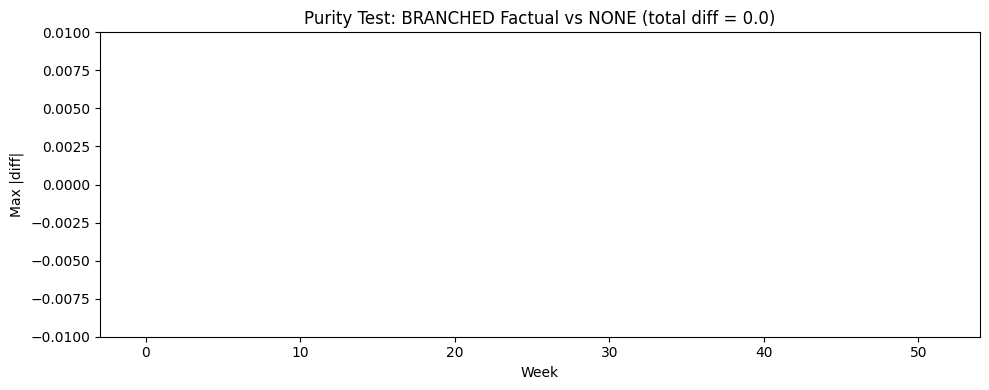

Total max difference: 0.0
PURITY TEST PASSED: BRANCHED factual is identical to NONE.
This proves: RNG partitioning, stream forking, step purity, clone correctness.


In [3]:
# Run NONE mode with same seed
scenario_n = StrokePreventionScenario(config=config, seed=seed)
engine_n = BranchedSimulationEngine(scenario_n, CounterfactualMode.NONE)
results_n = engine_n.run(config.n_patients)

# Compare factual outcomes element-wise at every timestep
max_diffs = []
for t in range(config.n_weeks):
    if t in results_b.outcomes and t in results_n.outcomes:
        diff = np.abs(results_b.outcomes[t].events - results_n.outcomes[t].events).max()
        max_diffs.append(diff)
    else:
        max_diffs.append(0.0)

total_diff = sum(max_diffs)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['red' if d > 0 else 'green' for d in max_diffs]
ax.bar(range(config.n_weeks), max_diffs, color=colors, alpha=0.7)
ax.set_xlabel('Week')
ax.set_ylabel('Max |diff|')
ax.set_title(f'Purity Test: BRANCHED Factual vs NONE (total diff = {total_diff})')
ax.set_ylim(-0.01, 0.01)
plt.tight_layout()
plt.show()

assert total_diff == 0.0, f"PURITY VIOLATION: total diff = {total_diff}"
print(f"Total max difference: {total_diff}")
print("PURITY TEST PASSED: BRANCHED factual is identical to NONE.")
print("This proves: RNG partitioning, stream forking, step purity, clone correctness.")

## 3. Intervention Effect

Plot factual vs counterfactual weekly incident rates to visualize
the causal effect of the AI-driven intervention.

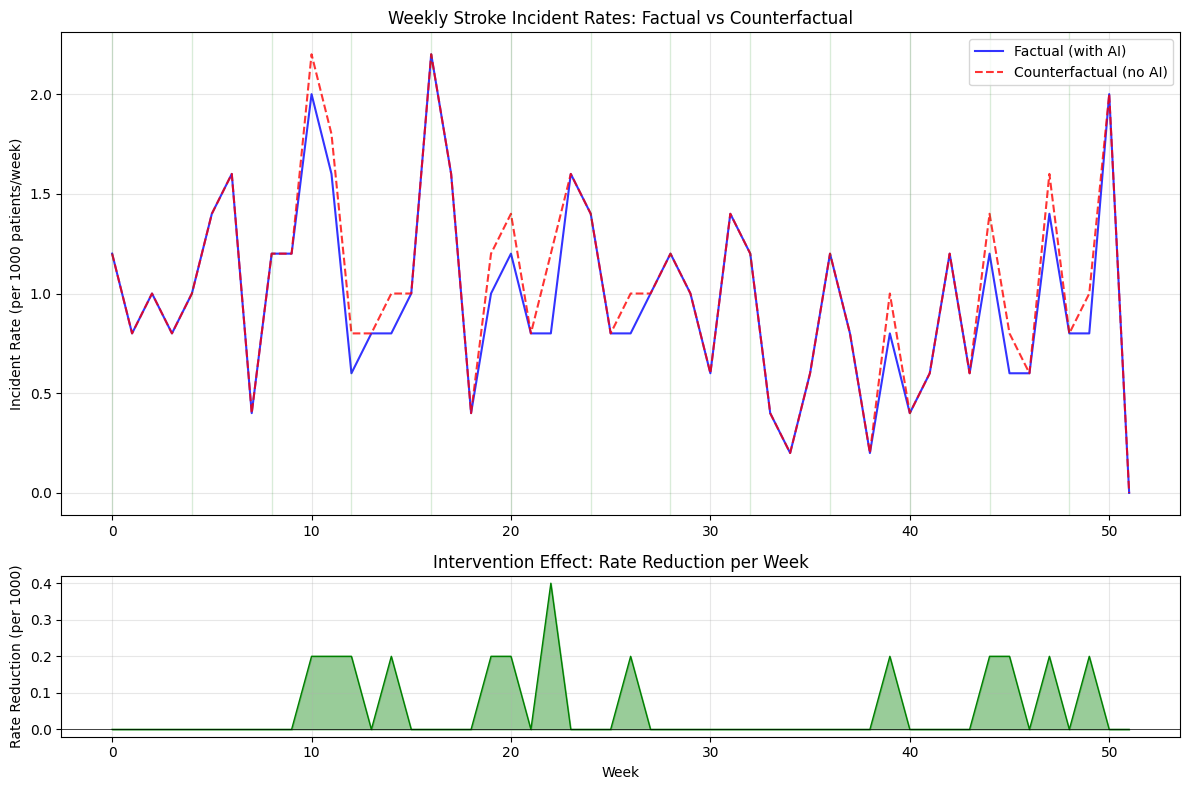

Mean factual weekly rate:        0.98 per 1000
Mean counterfactual weekly rate:  1.03 per 1000
Mean weekly reduction:            0.05 per 1000


In [4]:
weeks = np.arange(config.n_weeks)
factual_rates = np.array([
    results_b.outcomes[t].events.mean() if t in results_b.outcomes else 0
    for t in range(config.n_weeks)
])
cf_rates = np.array([
    results_b.counterfactual_outcomes[t].events.mean() if t in results_b.counterfactual_outcomes else 0
    for t in range(config.n_weeks)
])

fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

ax = axes[0]
ax.plot(weeks, factual_rates * 1000, 'b-', linewidth=1.5, alpha=0.8, label='Factual (with AI)')
ax.plot(weeks, cf_rates * 1000, 'r--', linewidth=1.5, alpha=0.8, label='Counterfactual (no AI)')
# Mark prediction/intervention weeks
pred_weeks = sorted(results_b.predictions.keys())
for pw in pred_weeks:
    ax.axvline(x=pw, color='green', alpha=0.15, linewidth=1)
ax.set_ylabel('Incident Rate (per 1000 patients/week)')
ax.set_title('Weekly Stroke Incident Rates: Factual vs Counterfactual')
ax.legend()
ax.grid(True, alpha=0.3)

# Difference plot
ax = axes[1]
reduction = (cf_rates - factual_rates) * 1000
ax.fill_between(weeks, 0, reduction, alpha=0.4, color='green', label='Strokes prevented')
ax.plot(weeks, reduction, 'g-', linewidth=1)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Week')
ax.set_ylabel('Rate Reduction (per 1000)')
ax.set_title('Intervention Effect: Rate Reduction per Week')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Mean factual weekly rate:        {factual_rates.mean()*1000:.2f} per 1000")
print(f"Mean counterfactual weekly rate:  {cf_rates.mean()*1000:.2f} per 1000")
print(f"Mean weekly reduction:            {reduction.mean():.2f} per 1000")

## 4. Analysis Exports

Show the shapes of `to_time_series()` and `to_panel()` exports.

In [5]:
ds = results_b.to_analysis()

# Time series
ts = ds.to_time_series(branch='factual')
print("=== to_time_series() ===")
print(f"  timesteps:          {ts['timesteps'].shape}")
print(f"  outcomes:           {ts['outcomes'].shape}")
print(f"  treatment_indicator: {ts['treatment_indicator'].shape}")
print(f"  treatment weeks:    {np.where(ts['treatment_indicator'] == 1)[0].tolist()}")

# Panel
panel = ds.to_panel(branch='factual')
print(f"\n=== to_panel() ===")
print(f"  entity_ids shape: {panel['entity_ids'].shape}")
print(f"  timesteps shape:  {panel['timesteps'].shape}")
print(f"  outcomes shape:   {panel['outcomes'].shape}")
print(f"  treated shape:    {panel['treated'].shape}")
print(f"  unit_of_analysis: '{panel['unit_of_analysis']}'")
print(f"  unique patients:  {len(np.unique(panel['entity_ids']))}")
print(f"  unique weeks:     {len(np.unique(panel['timesteps']))}")
print(f"  total rows:       {len(panel['entity_ids'])}")
print(f"  expected rows:    {config.n_patients * config.n_weeks}")

assert len(panel['entity_ids']) == config.n_patients * config.n_weeks
print("\nPanel shape check PASSED")

=== to_time_series() ===
  timesteps:          (52,)
  outcomes:           (52,)
  treatment_indicator: (52,)
  treatment weeks:    [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48]

=== to_panel() ===
  entity_ids shape: (260000,)
  timesteps shape:  (260000,)
  outcomes shape:   (260000,)
  treated shape:    (260000,)
  unit_of_analysis: 'patient'
  unique patients:  5000
  unique weeks:     52
  total rows:       260000
  expected rows:    260000

Panel shape check PASSED


## Key Insights

This notebook validates **all Phase 1 invariants** composed together in the stroke prevention scenario:

1. **RNG Partitioning** (NB01): The stroke scenario uses 5 independent streams — `population`, `temporal`, `prediction`, `intervention`, `outcomes` — ensuring that adding/removing model predictions does not change disease progression.
2. **State & Clone** (NB02): The 4-row state array stores all dynamic quantities (base risks, AR(1) modifiers, treatment effects, current risks). `clone_state()` produces a true copy via `state.copy()`.
3. **Discrete-Time Engine** (NB03): The `BranchedSimulationEngine` runs the scenario step-by-step with BRANCHED mode, maintaining parallel factual and counterfactual trajectories.
4. **Step Purity** (NB04): The purity test passes — BRANCHED factual is element-wise identical to NONE, proving no shared mutable state leaks between branches.
5. **ML Binary Classifier** (NB05): `ControlledBinaryClassifier` generates predictions that hit target PPV/sensitivity, driving the intervention decisions.
6. **Analysis-Ready Data** (NB07): `AnalysisDataset` exports time series and panel data with correct shapes for downstream causal analysis.

**Phase 1 is complete.** All invariants are individually validated and proven to compose correctly in a realistic clinical scenario.